
# PCA and Clustering Analysis - Wine Dataset



In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings 
warnings.filterwarnings('ignore')

In [19]:

# Load Dataset
df = pd.read_csv("wine.csv")


In [20]:
print("First 5 rows:")
df.head()

First 5 rows:


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [21]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [22]:
print("\nMissing Values:")
df.isnull().sum()



Missing Values:


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

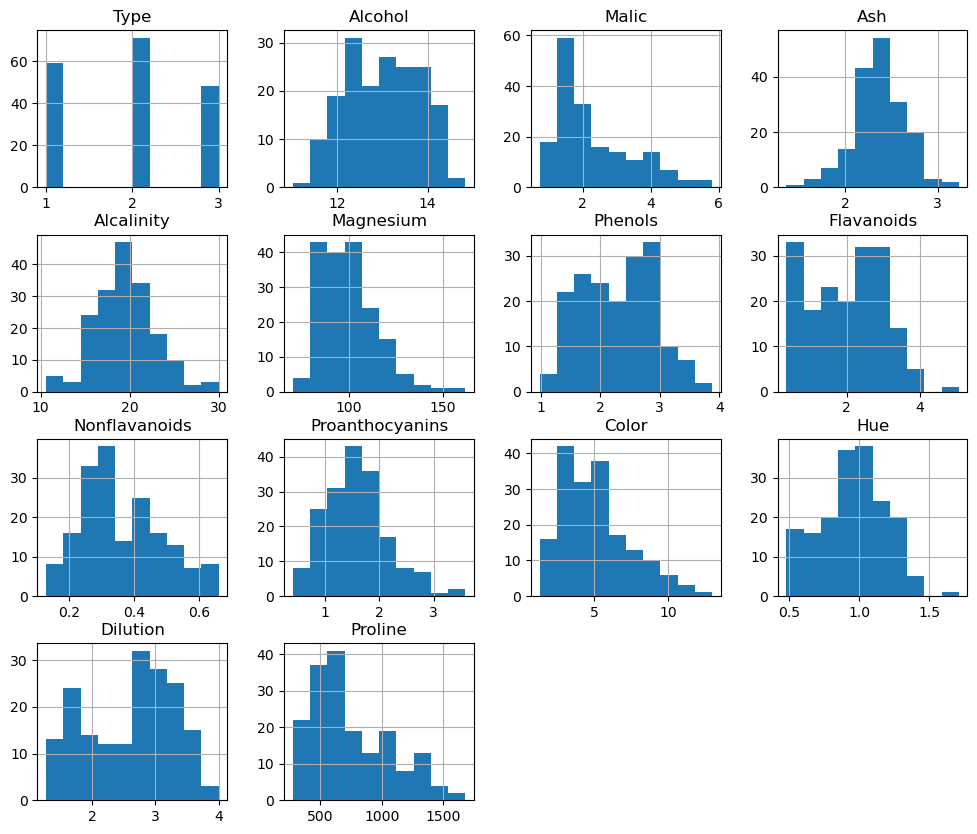

In [23]:

# Histograms
df.hist(figsize=(12,10))
plt.show()



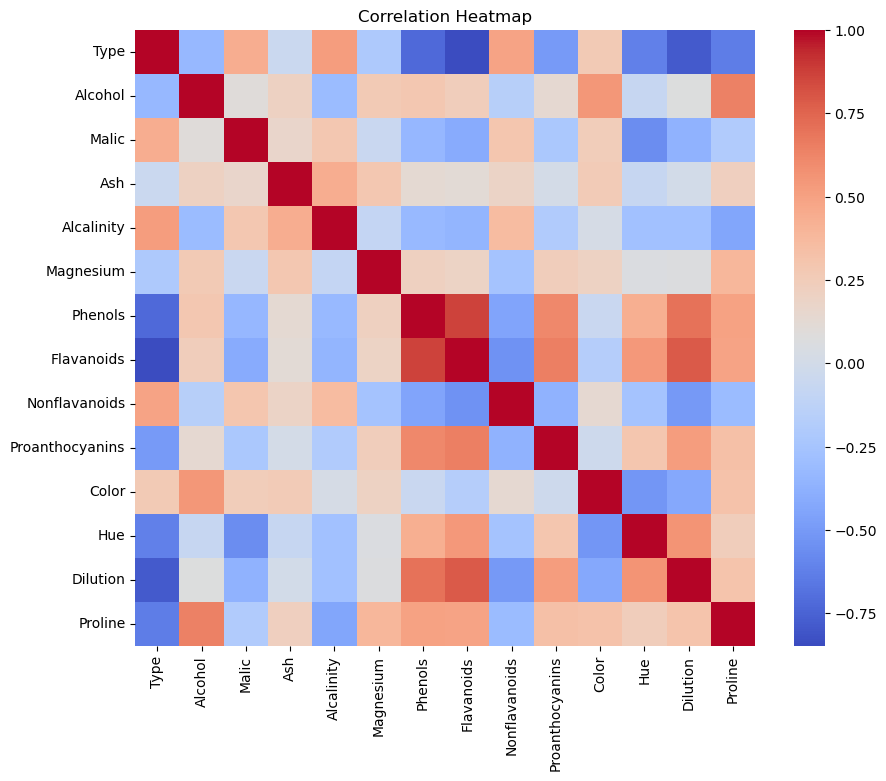

In [24]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [25]:

# Separate features (modify if your dataset has different target column)
if 'target' in df.columns:
    X = df.drop(columns=['target'])
else:
    X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


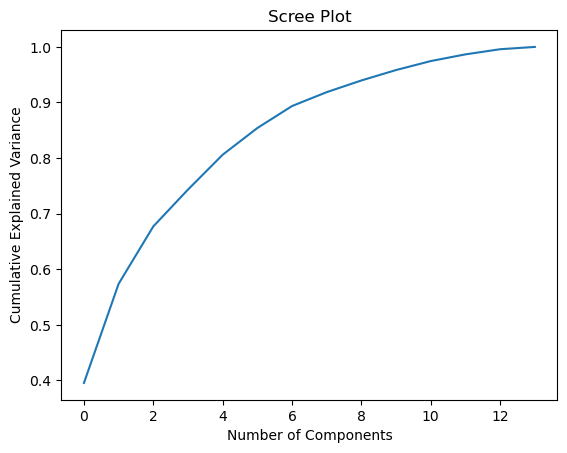

In [26]:

# Apply PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Scree Plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()


In [27]:

# Reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [28]:

# KMeans on Original Data
kmeans_original = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans_original.fit_predict(X_scaled)

score_original = silhouette_score(X_scaled, clusters_original)
print("Silhouette Score (Original Data):", score_original)


Silhouette Score (Original Data): 0.30648398324833453


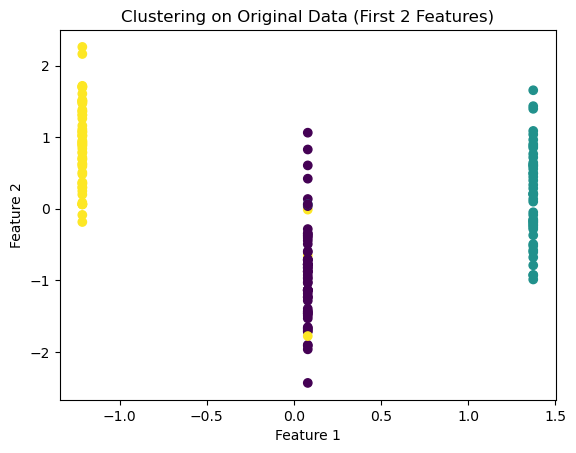

In [29]:

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_original)
plt.title("Clustering on Original Data (First 2 Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [30]:

# KMeans on PCA Data
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

score_pca = silhouette_score(X_pca, clusters_pca)
print("Silhouette Score (PCA Data):", score_pca)


Silhouette Score (PCA Data): 0.6024415520362845


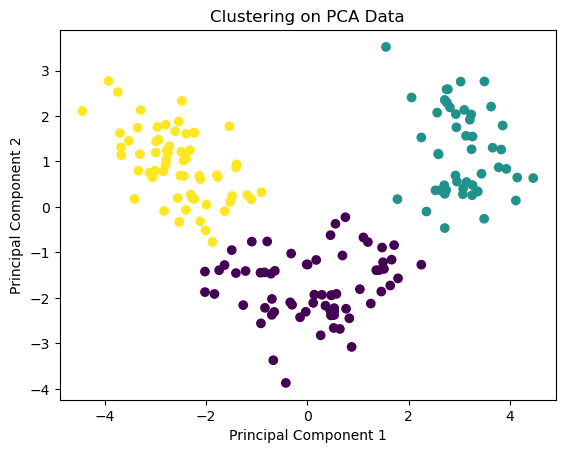

In [31]:

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca)
plt.title("Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()



## Comparison and Analysis

- PCA reduces dimensionality while preserving maximum variance.
- Clustering after PCA improves visualization.
- Silhouette scores help evaluate clustering quality.
- PCA may slightly reduce information but improves computational efficiency.



## Conclusion

PCA is an effective dimensionality reduction technique that improves clustering interpretability and efficiency.  
Clustering on PCA-transformed data provides easier visualization with comparable performance.
